# Modélisation de la probabilité de sinistre

L’objectif est de prédire si un contrat aura au moins un sinistre pendant une période donnée.

La cible utilisée est `Has_Claim` :

- `0` : aucun sinistre ;
- `1` : au moins un sinistre.

Une régression logistique sera utilisée comme modèle baseline interprétable. Elle sera comparée à un modèle naïf afin de vérifier qu’elle apporte réellement une information prédictive.

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import json
import joblib

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [82]:
data_path = Path(
    "../data/processed/cleaned_data.csv"
)

df = pd.read_csv(data_path)

In [83]:
print(f"Dimensions : {df.shape}")
print(f"Années : {sorted(df['year'].unique())}")

Dimensions : (122935, 26)
Années : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [84]:
numerical_features = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

binary_features = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment"
]

feature_columns = (
    numerical_features
    + binary_features
)

target_column = "Has_Claim"

In [85]:
train_mask = df["year"].isin([1, 2, 3])
validation_mask = df["year"] == 4
test_mask = df["year"] == 5

In [86]:
X_train = df.loc[
    train_mask,
    feature_columns
].copy()

y_train = df.loc[
    train_mask,
    target_column
].copy()

X_validation = df.loc[
    validation_mask,
    feature_columns
].copy()

y_validation = df.loc[
    validation_mask,
    target_column
].copy()

X_test = df.loc[
    test_mask,
    feature_columns
].copy()

y_test = df.loc[
    test_mask,
    target_column
].copy()

In [87]:
split_summary = pd.DataFrame({
    "Ensemble": [
        "Entraînement",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Taux_sinistre_pct": [
        y_train.mean() * 100,
        y_validation.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary.round(2)

,Ensemble,Observations,Taux_sinistre_pct
0,Entraînement,92607,5.79
1,Validation,17044,5.07
2,Test,13284,4.67


## 1. Modèle naïf de référence

Le modèle naïf ne cherche aucune relation entre les variables explicatives et la cible. Il sert de point de comparaison minimal.

Un modèle de Machine Learning utile doit apporter de meilleures performances que cette référence.

In [88]:
dummy_model = DummyClassifier(
    strategy="prior"
)

In [89]:
dummy_model.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.94,0.06]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,13
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [90]:
dummy_predictions = dummy_model.predict(
    X_validation
)

dummy_probabilities = (
    dummy_model.predict_proba(
        X_validation
    )[:, 1]
)

In [91]:
def evaluate_classifier(
    model_name,
    y_true,
    predictions,
    probabilities
):
    results = {
        "Modele": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1_score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        )
    }

    return results

In [92]:
dummy_results = evaluate_classifier(
    model_name="Dummy Classifier",
    y_true=y_validation,
    predictions=dummy_predictions,
    probabilities=dummy_probabilities
)

pd.DataFrame([dummy_results]).round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,0.9493,0.0,0.0,0.0,0.5,0.0507


In [93]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [94]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [95]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

In [96]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that genera

In [97]:
logistic_predictions = (
    logistic_pipeline.predict(
        X_validation
    )
)

logistic_probabilities = (
    logistic_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

In [98]:
logistic_probabilities[:10]

array([0.32493922, 0.44789914, 0.49598566, 0.48239444, 0.47216542,
       0.43911812, 0.30386289, 0.28720162, 0.43974349, 0.54455752])

In [99]:
assert (
    (logistic_probabilities >= 0)
    & (logistic_probabilities <= 1)
).all()

print("Toutes les probabilités sont valides.")

Toutes les probabilités sont valides.


In [100]:
logistic_results = evaluate_classifier(
    model_name="Régression logistique",
    y_true=y_validation,
    predictions=logistic_predictions,
    probabilities=logistic_probabilities
)

In [101]:
validation_results = pd.DataFrame([
    dummy_results,
    logistic_results
])

validation_results.round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,0.9493,0.0000,0.0000,0.0000,0.5000,0.0507
1,Régression logistique,0.5709,0.0675,0.5822,0.1209,0.6194,0.0729


In [102]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_score",
    "ROC_AUC",
    "PR_AUC"
]

validation_results_percent = (
    validation_results.copy()
)

validation_results_percent[
    metric_columns
] *= 100

validation_results_percent.round(2)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,94.93,0.00,0.00,0.00,50.00,5.07
1,Régression logistique,57.09,6.75,58.22,12.09,61.94,7.29


In [103]:
print(
    classification_report(
        y_validation,
        logistic_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9624    0.5703    0.7162     16180
           1     0.0675    0.5822    0.1209       864

    accuracy                         0.5709     17044
   macro avg     0.5149    0.5763    0.4186     17044
weighted avg     0.9170    0.5709    0.6860     17044



In [104]:
logistic_confusion_matrix = confusion_matrix(
    y_validation,
    logistic_predictions
)

logistic_confusion_matrix

array([[9228, 6952],
       [ 361,  503]])

In [105]:
tn, fp, fn, tp = (
    logistic_confusion_matrix.ravel()
)

print(f"Vrais négatifs  : {tn}")
print(f"Faux positifs   : {fp}")
print(f"Faux négatifs   : {fn}")
print(f"Vrais positifs  : {tp}")

Vrais négatifs  : 9228
Faux positifs   : 6952
Faux négatifs   : 361
Vrais positifs  : 503


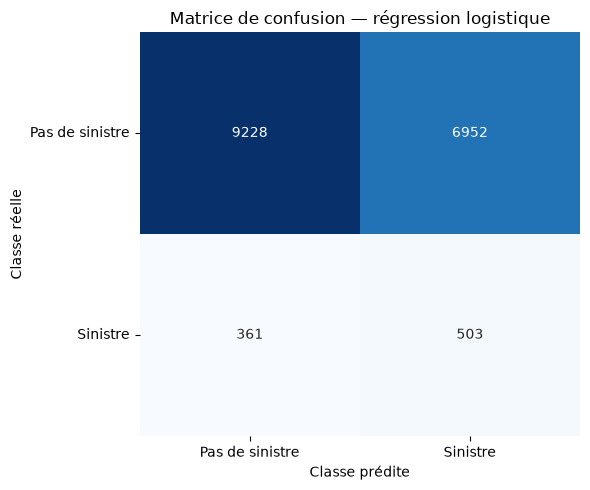

In [106]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Matrice de confusion — régression logistique"
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"]
)
plt.yticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [107]:
normalized_confusion_matrix = confusion_matrix(
    y_validation,
    logistic_predictions,
    normalize="true"
)

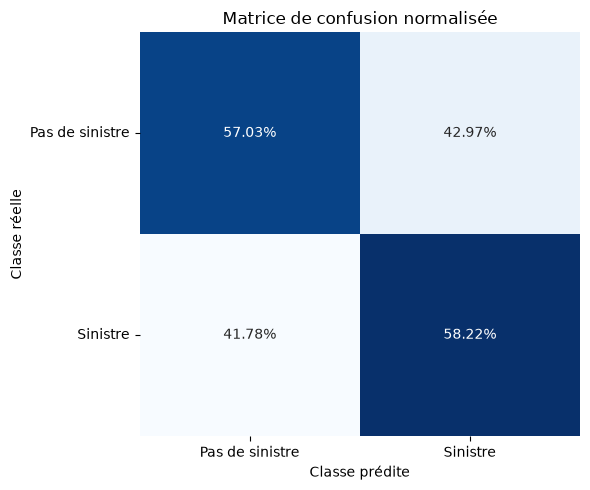

In [108]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    normalized_confusion_matrix,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Matrice de confusion normalisée"
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"]
)
plt.yticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"],
    rotation=0
)

plt.tight_layout()
plt.show()

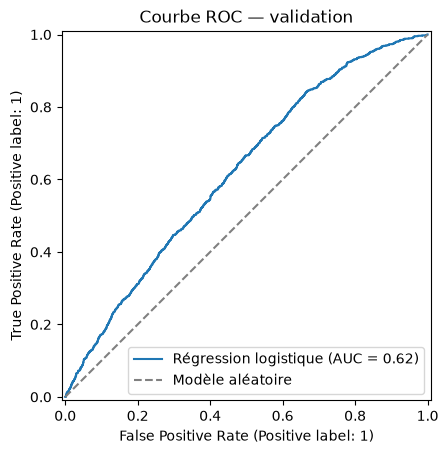

In [109]:
RocCurveDisplay.from_predictions(
    y_validation,
    logistic_probabilities,
    name="Régression logistique"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Modèle aléatoire"
)

plt.title("Courbe ROC — validation")
plt.legend()
plt.show()

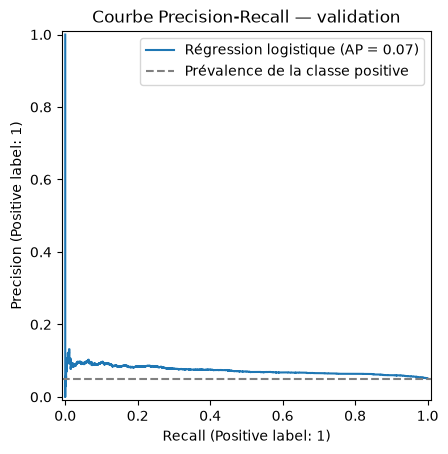

In [110]:
PrecisionRecallDisplay.from_predictions(
    y_validation,
    logistic_probabilities,
    name="Régression logistique"
)

baseline_rate = y_validation.mean()

plt.axhline(
    y=baseline_rate,
    linestyle="--",
    color="gray",
    label="Prévalence de la classe positive"
)

plt.title(
    "Courbe Precision-Recall — validation"
)
plt.legend()
plt.show()

In [111]:
def evaluate_thresholds(
    y_true,
    probabilities,
    thresholds
):
    threshold_results = []

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        threshold_results.append({
            "Seuil": threshold,
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "F1_score": f1_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Nombre_predits_positifs": (
                predictions.sum()
            )
        })

    return pd.DataFrame(
        threshold_results
    )

In [112]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

In [113]:
threshold_results = evaluate_thresholds(
    y_true=y_validation,
    probabilities=logistic_probabilities,
    thresholds=thresholds
)

threshold_results.head()

,Seuil,Precision,Recall,F1_score,Nombre_predits_positifs
0,0.05,0.050692,1.0,0.096493,17044
1,0.06,0.050692,1.0,0.096493,17044
2,0.07,0.050692,1.0,0.096493,17044
3,0.08,0.050692,1.0,0.096493,17044
4,0.09,0.050692,1.0,0.096493,17044


In [114]:
best_f1_row = threshold_results.loc[
    threshold_results[
        "F1_score"
    ].idxmax()
]

best_f1_row

Seuil                         0.540000
Precision                     0.074443
Recall                        0.406250
F1_score                      0.125829
Nombre_predits_positifs    4715.000000
Name: 49, dtype: float64

In [115]:
best_f1_threshold = best_f1_row["Seuil"]

print(
    "Meilleur seuil selon le F1-score : "
    f"{best_f1_threshold:.2f}"
)

Meilleur seuil selon le F1-score : 0.54


In [116]:
minimum_recall = 0.70

eligible_thresholds = threshold_results[
    threshold_results["Recall"] >= minimum_recall
]

In [117]:
if not eligible_thresholds.empty:
    risk_oriented_row = eligible_thresholds.loc[
        eligible_thresholds[
            "Precision"
        ].idxmax()
    ]

    risk_oriented_threshold = (
        risk_oriented_row["Seuil"]
    )

    display(risk_oriented_row)
else:
    print(
        "Aucun seuil n'atteint le rappel demandé."
    )

Seuil                         0.470000
Precision                     0.065347
Recall                        0.710648
F1_score                      0.119688
Nombre_predits_positifs    9396.000000
Name: 42, dtype: float64

In [118]:
threshold_plot = threshold_results.melt(
    id_vars="Seuil",
    value_vars=[
        "Precision",
        "Recall",
        "F1_score"
    ],
    var_name="Metrique",
    value_name="Valeur"
)

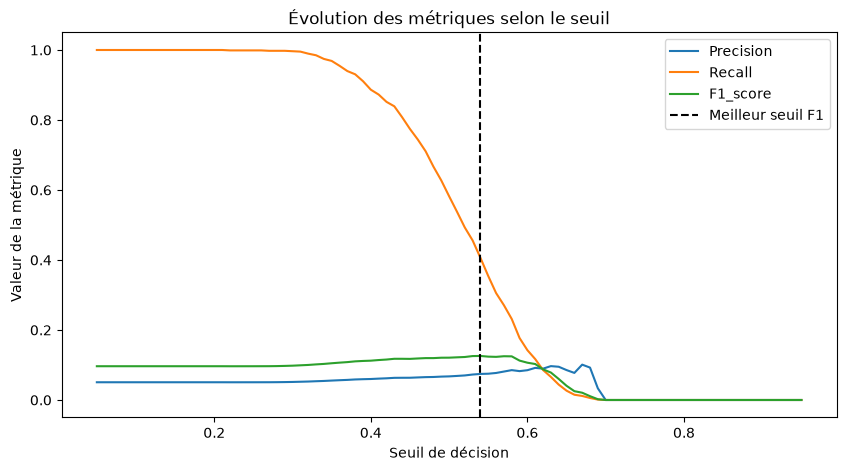

In [119]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=threshold_plot,
    x="Seuil",
    y="Valeur",
    hue="Metrique"
)

plt.axvline(
    x=best_f1_threshold,
    color="black",
    linestyle="--",
    label="Meilleur seuil F1"
)

plt.title(
    "Évolution des métriques selon le seuil"
)
plt.xlabel("Seuil de décision")
plt.ylabel("Valeur de la métrique")
plt.legend()
plt.show()

In [120]:
optimized_predictions = (
    logistic_probabilities
    >= best_f1_threshold
).astype(int)

In [121]:
optimized_results = evaluate_classifier(
    model_name=(
        "Régression logistique "
        "avec seuil optimisé"
    ),
    y_true=y_validation,
    predictions=optimized_predictions,
    probabilities=logistic_probabilities
)

In [122]:
threshold_comparison = pd.DataFrame([
    logistic_results,
    optimized_results
])

threshold_comparison.round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Régression logistique,0.5709,0.0675,0.5822,0.1209,0.6194,0.0729
1,Régression logistique avec seuil optimisé,0.7139,0.0744,0.4062,0.1258,0.6194,0.0729


In [123]:
selected_logistic_threshold = (
    best_f1_threshold
)

### Décision provisoire sur le seuil

Le seuil de décision a été étudié uniquement sur l’année de validation.

Deux approches ont été comparées :

- maximisation du F1-score ;
- rappel minimal orienté gestion des risques.

Le seuil reste provisoire jusqu’à la comparaison avec d’autres modèles. L’année 5 n’est pas utilisée à ce stade afin de préserver une évaluation finale indépendante.

## 3. Interprétation de la régression logistique

Les coefficients permettent d’étudier le sens de l’association entre chaque variable et la probabilité prédite de sinistre.

Cette interprétation reste une association statistique et ne démontre pas une causalité.

In [124]:
fitted_logistic_model = (
    logistic_pipeline
    .named_steps["model"]
)

In [125]:
fitted_preprocessor = (
    logistic_pipeline
    .named_steps["preprocessing"]
)

In [126]:
fitted_logistic_model = (
    logistic_pipeline.named_steps["model"]
)

fitted_preprocessor = (
    logistic_pipeline.named_steps["preprocessing"]
)

processed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

coefficient_table = pd.DataFrame({
    "Variable": processed_feature_names,
    "Coefficient": fitted_logistic_model.coef_[0]
})

coefficient_table

,Variable,Coefficient
0,Age_client,-0.142966
1,age_of_car_M,-0.033984
2,Car_power_M,-0.027204
3,Insuredcapital_content_re,0.040547
4,Insuredcapital_continent_re,0.099983
5,Client_Seniority,-0.046144
6,gender,0.075033
7,Car_2ndDriver_M,0.250924
8,num_policiesC,-0.056375
9,metro_code,-0.083346


In [127]:
coefficient_table["Coefficient_absolu"] = (
    coefficient_table["Coefficient"].abs()
)

In [128]:
coefficient_table = (
    coefficient_table
    .sort_values(
        by="Coefficient_absolu",
        ascending=False
    )
)

coefficient_table.round(4)

,Variable,Coefficient,Coefficient_absolu
12,appartment,0.6997,0.6997
7,Car_2ndDriver_M,0.2509,0.2509
10,Policy_PaymentMethodA,-0.2004,0.2004
0,Age_client,-0.1430,0.1430
11,Policy_PaymentMethodH,-0.1053,0.1053
4,Insuredcapital_continent_re,0.1000,0.1000
9,metro_code,-0.0833,0.0833
6,gender,0.0750,0.0750
8,num_policiesC,-0.0564,0.0564
5,Client_Seniority,-0.0461,0.0461


In [129]:
coefficient_table["Odds_ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table.round(4)

,Variable,Coefficient,Coefficient_absolu,Odds_ratio
12,appartment,0.6997,0.6997,2.0132
7,Car_2ndDriver_M,0.2509,0.2509,1.2852
10,Policy_PaymentMethodA,-0.2004,0.2004,0.8184
0,Age_client,-0.1430,0.1430,0.8668
11,Policy_PaymentMethodH,-0.1053,0.1053,0.9000
4,Insuredcapital_continent_re,0.1000,0.1000,1.1052
9,metro_code,-0.0833,0.0833,0.9200
6,gender,0.0750,0.0750,1.0779
8,num_policiesC,-0.0564,0.0564,0.9452
5,Client_Seniority,-0.0461,0.0461,0.9549


In [130]:
coefficient_plot_data = (
    coefficient_table
    .sort_values(
        by="Coefficient",
        ascending=True
    )
)

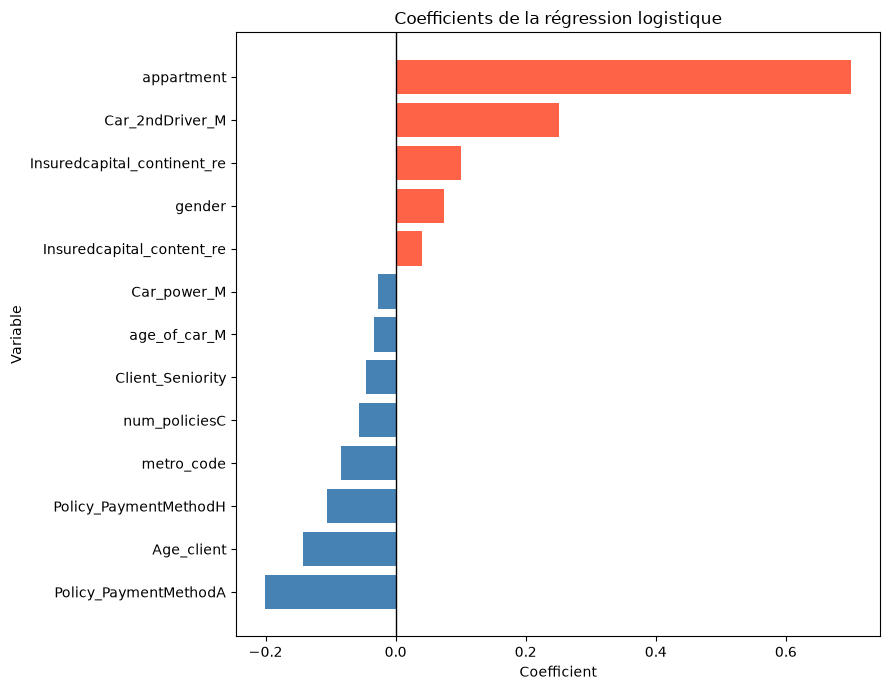

In [131]:
plt.figure(figsize=(9, 7))

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in coefficient_plot_data[
        "Coefficient"
    ]
]

plt.barh(
    coefficient_plot_data["Variable"],
    coefficient_plot_data["Coefficient"],
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title(
    "Coefficients de la régression logistique"
)
plt.xlabel("Coefficient")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 4. Random Forest

Random Forest combine plusieurs arbres de décision. Contrairement à la régression logistique, il peut apprendre des relations non linéaires et des interactions entre variables.

Ce premier Random Forest sert de comparaison. Ses hyperparamètres seront ensuite ajustés uniquement à partir de la validation.

In [133]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "features",
            "passthrough",
            feature_columns
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [134]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [135]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            tree_preprocessor
        ),
        (
            "model",
            random_forest_model
        )
    ]
)

In [136]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('features', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. 

In [137]:
random_forest_predictions = (
    random_forest_pipeline.predict(
        X_validation
    )
)

random_forest_probabilities = (
    random_forest_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

In [138]:
assert (
    (random_forest_probabilities >= 0)
    & (random_forest_probabilities <= 1)
).all()

print("Les probabilités Random Forest sont valides.")

Les probabilités Random Forest sont valides.


In [139]:
random_forest_results = evaluate_classifier(
    model_name="Random Forest",
    y_true=y_validation,
    predictions=random_forest_predictions,
    probabilities=random_forest_probabilities
)

In [140]:
model_comparison = pd.DataFrame([
    dummy_results,
    logistic_results,
    random_forest_results
])

model_comparison.round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,0.9493,0.0000,0.0000,0.0000,0.5000,0.0507
1,Régression logistique,0.5709,0.0675,0.5822,0.1209,0.6194,0.0729
2,Random Forest,0.7208,0.0832,0.4502,0.1405,0.6541,0.0901


In [141]:
model_comparison_percent = (
    model_comparison.copy()
)

model_comparison_percent[
    metric_columns
] *= 100

model_comparison_percent.round(2)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,94.93,0.00,0.00,0.00,50.00,5.07
1,Régression logistique,57.09,6.75,58.22,12.09,61.94,7.29
2,Random Forest,72.08,8.32,45.02,14.05,65.41,9.01


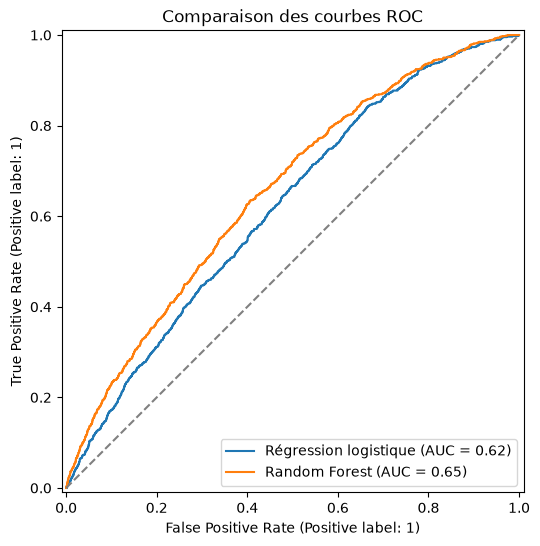

In [142]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

RocCurveDisplay.from_predictions(
    y_validation,
    logistic_probabilities,
    name="Régression logistique",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_validation,
    random_forest_probabilities,
    name="Random Forest",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

ax.set_title(
    "Comparaison des courbes ROC"
)

plt.show()

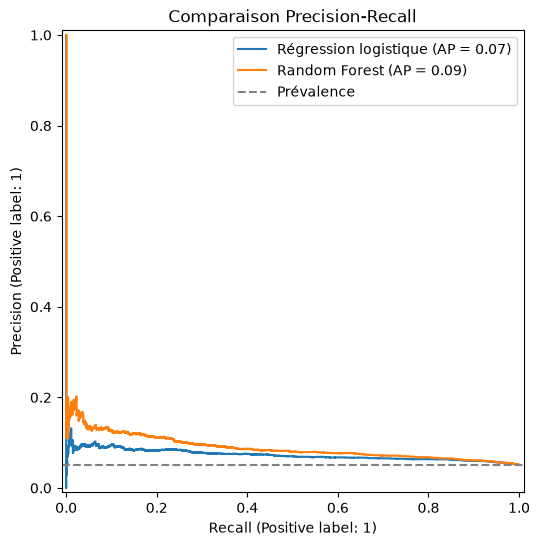

In [143]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

PrecisionRecallDisplay.from_predictions(
    y_validation,
    logistic_probabilities,
    name="Régression logistique",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_validation,
    random_forest_probabilities,
    name="Random Forest",
    ax=ax
)

ax.axhline(
    y=y_validation.mean(),
    linestyle="--",
    color="gray",
    label="Prévalence"
)

ax.set_title(
    "Comparaison Precision-Recall"
)

ax.legend()

plt.show()

### Critères de comparaison

Le modèle ne sera pas choisi uniquement selon l’accuracy, car la classe sans sinistre est largement majoritaire.

Les métriques principales sont :

- la PR-AUC pour la performance sur la classe rare ;
- la ROC-AUC pour la capacité de classement ;
- le recall pour limiter les sinistres non détectés ;
- la précision pour maîtriser les fausses alertes ;
- le F1-score pour équilibrer précision et rappel.

Le seuil de chaque modèle devra être ajusté sur la validation avant la comparaison finale.

In [144]:
random_forest_threshold_results = (
    evaluate_thresholds(
        y_true=y_validation,
        probabilities=random_forest_probabilities,
        thresholds=thresholds
    )
)

random_forest_threshold_results.head()

,Seuil,Precision,Recall,F1_score,Nombre_predits_positifs
0,0.05,0.050701,1.0,0.096509,17041
1,0.06,0.050707,1.0,0.096520,17039
2,0.07,0.050725,1.0,0.096552,17033
3,0.08,0.050743,1.0,0.096585,17027
4,0.09,0.050818,1.0,0.096720,17002


In [145]:
best_rf_f1_row = (
    random_forest_threshold_results.loc[
        random_forest_threshold_results[
            "F1_score"
        ].idxmax()
    ]
)

best_rf_f1_row

Seuil                         0.560000
Precision                     0.109827
Recall                        0.219907
F1_score                      0.146492
Nombre_predits_positifs    1730.000000
Name: 51, dtype: float64

In [146]:
best_rf_threshold = (
    best_rf_f1_row["Seuil"]
)

print(
    "Meilleur seuil Random Forest : "
    f"{best_rf_threshold:.2f}"
)

Meilleur seuil Random Forest : 0.56


In [147]:
random_forest_optimized_predictions = (
    random_forest_probabilities
    >= best_rf_threshold
).astype(int)

In [148]:
random_forest_optimized_results = (
    evaluate_classifier(
        model_name=(
            "Random Forest avec seuil optimisé"
        ),
        y_true=y_validation,
        predictions=(
            random_forest_optimized_predictions
        ),
        probabilities=(
            random_forest_probabilities
        )
    )
)

In [149]:
optimized_model_comparison = pd.DataFrame([
    optimized_results,
    random_forest_optimized_results
])

optimized_model_comparison.round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Régression logistique avec seuil optimisé,0.7139,0.0744,0.4062,0.1258,0.6194,0.0729
1,Random Forest avec seuil optimisé,0.8701,0.1098,0.2199,0.1465,0.6541,0.0901


In [150]:
rf_threshold_plot = (
    random_forest_threshold_results
    .melt(
        id_vars="Seuil",
        value_vars=[
            "Precision",
            "Recall",
            "F1_score"
        ],
        var_name="Metrique",
        value_name="Valeur"
    )
)

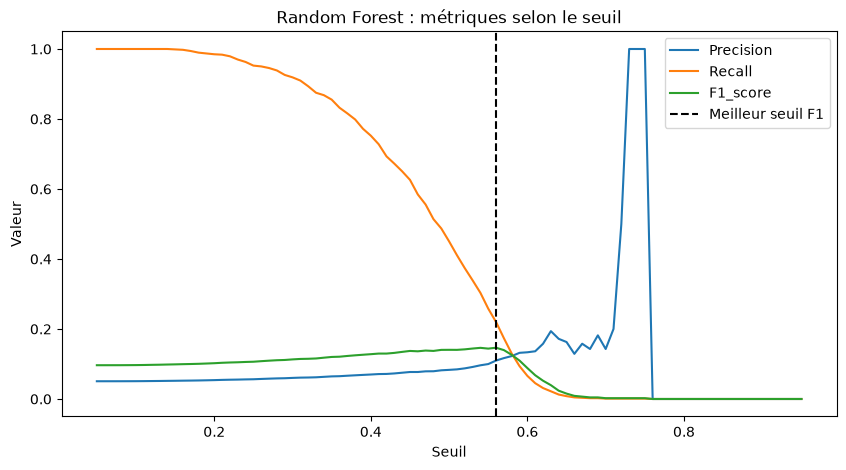

In [151]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=rf_threshold_plot,
    x="Seuil",
    y="Valeur",
    hue="Metrique"
)

plt.axvline(
    x=best_rf_threshold,
    color="black",
    linestyle="--",
    label="Meilleur seuil F1"
)

plt.title(
    "Random Forest : métriques selon le seuil"
)
plt.xlabel("Seuil")
plt.ylabel("Valeur")
plt.legend()
plt.show()

In [152]:
fitted_random_forest = (
    random_forest_pipeline
    .named_steps["model"]
)

In [153]:
rf_feature_names = (
    random_forest_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

In [154]:
rf_importance_table = pd.DataFrame({
    "Variable": rf_feature_names,
    "Importance": (
        fitted_random_forest
        .feature_importances_
    )
})

In [155]:
rf_importance_table = (
    rf_importance_table
    .sort_values(
        by="Importance",
        ascending=False
    )
)

rf_importance_table.round(4)

,Variable,Importance
5,Client_Seniority,0.1653
4,Insuredcapital_continent_re,0.1632
3,Insuredcapital_content_re,0.1490
0,Age_client,0.1451
2,Car_power_M,0.1142
12,appartment,0.0910
1,age_of_car_M,0.0847
10,Policy_PaymentMethodA,0.0201
7,Car_2ndDriver_M,0.0158
6,gender,0.0147


In [156]:
print(
    "Somme des importances : "
    f"{rf_importance_table['Importance'].sum():.4f}"
)

Somme des importances : 1.0000


In [157]:
rf_importance_plot = (
    rf_importance_table
    .sort_values(
        by="Importance",
        ascending=True
    )
)

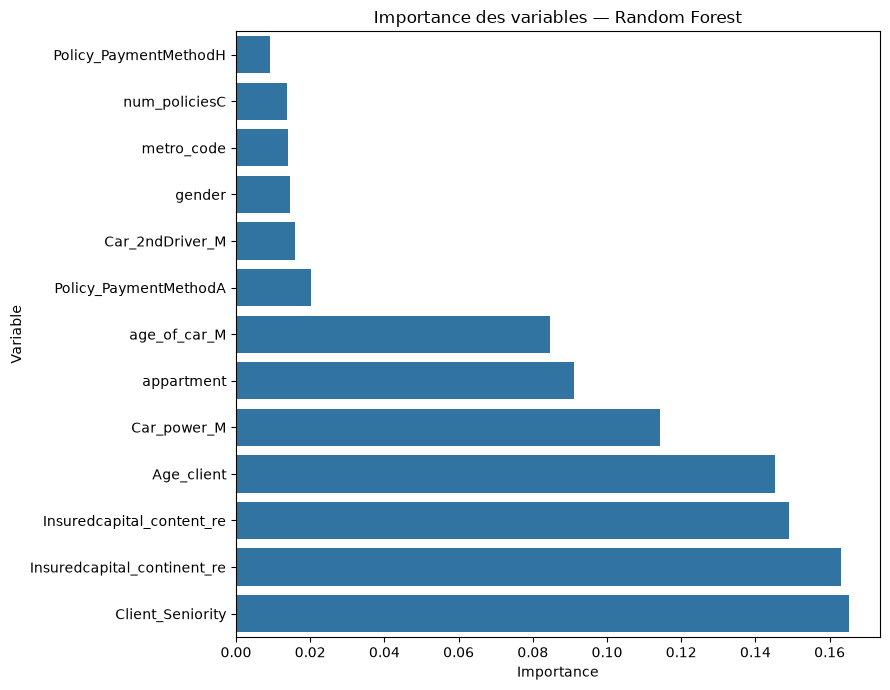

In [158]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=rf_importance_plot,
    x="Importance",
    y="Variable"
)

plt.title(
    "Importance des variables — Random Forest"
)
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [159]:
validation_sample_size = min(
    10000,
    len(X_validation)
)

validation_sample_indices = (
    X_validation
    .sample(
        n=validation_sample_size,
        random_state=42
    )
    .index
)

In [160]:
X_validation_sample = X_validation.loc[
    validation_sample_indices
]

y_validation_sample = y_validation.loc[
    validation_sample_indices
]

In [163]:
permutation_results = permutation_importance(
    estimator=random_forest_pipeline,
    X=X_validation_sample,
    y=y_validation_sample,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [164]:
permutation_table = pd.DataFrame({
    "Variable": feature_columns,
    "Importance_moyenne": (
        permutation_results
        .importances_mean
    ),
    "Ecart_type": (
        permutation_results
        .importances_std
    )
})

In [165]:
permutation_table = (
    permutation_table
    .sort_values(
        by="Importance_moyenne",
        ascending=False
    )
)

permutation_table.round(5)

,Variable,Importance_moyenne,Ecart_type
12,appartment,0.02132,0.00363
0,Age_client,0.01983,0.00269
3,Insuredcapital_content_re,0.01466,0.00162
4,Insuredcapital_continent_re,0.01434,0.00317
2,Car_power_M,0.01141,0.00145
5,Client_Seniority,0.01031,0.00371
1,age_of_car_M,0.00861,0.00272
10,Policy_PaymentMethodA,0.00593,0.00189
11,Policy_PaymentMethodH,0.00313,0.00041
7,Car_2ndDriver_M,0.00293,0.00106


In [166]:
permutation_plot = (
    permutation_table
    .sort_values(
        by="Importance_moyenne",
        ascending=True
    )
)

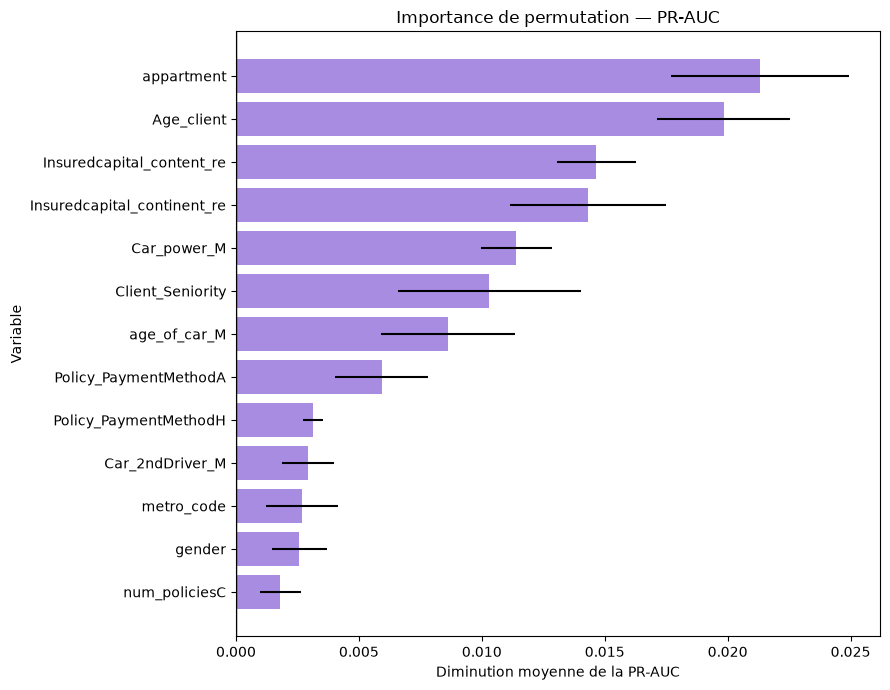

In [167]:
plt.figure(figsize=(9, 7))

plt.barh(
    permutation_plot["Variable"],
    permutation_plot["Importance_moyenne"],
    xerr=permutation_plot["Ecart_type"],
    color="mediumpurple",
    alpha=0.8
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title(
    "Importance de permutation — PR-AUC"
)
plt.xlabel(
    "Diminution moyenne de la PR-AUC"
)
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [168]:
final_validation_comparison = pd.DataFrame([
    dummy_results,
    logistic_results,
    optimized_results,
    random_forest_results,
    random_forest_optimized_results
])

final_validation_comparison.round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,0.9493,0.0000,0.0000,0.0000,0.5000,0.0507
1,Régression logistique,0.5709,0.0675,0.5822,0.1209,0.6194,0.0729
2,Régression logistique avec seuil optimisé,0.7139,0.0744,0.4062,0.1258,0.6194,0.0729
3,Random Forest,0.7208,0.0832,0.4502,0.1405,0.6541,0.0901
4,Random Forest avec seuil optimisé,0.8701,0.1098,0.2199,0.1465,0.6541,0.0901


In [169]:
final_validation_comparison.sort_values(
    by="PR_AUC",
    ascending=False
).round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
4,Random Forest avec seuil optimisé,0.8701,0.1098,0.2199,0.1465,0.6541,0.0901
3,Random Forest,0.7208,0.0832,0.4502,0.1405,0.6541,0.0901
2,Régression logistique avec seuil optimisé,0.7139,0.0744,0.4062,0.1258,0.6194,0.0729
1,Régression logistique,0.5709,0.0675,0.5822,0.1209,0.6194,0.0729
0,Dummy Classifier,0.9493,0.0000,0.0000,0.0000,0.5000,0.0507


## Conclusion provisoire

Les modèles sont comparés sur l’année 4, qui constitue l’ensemble de validation.

La PR-AUC et la ROC-AUC évaluent la qualité du classement produit par les probabilités. Elles ne changent pas lors de l’ajustement du seuil.

Le seuil modifie en revanche la précision, le rappel et le F1-score. Son choix doit refléter le coût métier des faux négatifs et des faux positifs.

Le meilleur modèle ne sera évalué sur l’année 5 qu’après la sélection définitive basée sur la validation.

In [171]:
selection_table = pd.DataFrame([
    logistic_results,
    random_forest_results
])

selection_table[
    [
        "Modele",
        "ROC_AUC",
        "PR_AUC"
    ]
].sort_values(
    by="PR_AUC",
    ascending=False
).round(4)

,Modele,ROC_AUC,PR_AUC
1,Random Forest,0.6541,0.0901
0,Régression logistique,0.6194,0.0729


In [172]:
candidate_scores = {
    "Régression logistique": (
        logistic_results["PR_AUC"]
    ),
    "Random Forest": (
        random_forest_results["PR_AUC"]
    )
}

selected_model_name = max(
    candidate_scores,
    key=candidate_scores.get
)

print(
    f"Modèle sélectionné : "
    f"{selected_model_name}"
)

Modèle sélectionné : Random Forest


In [173]:
candidate_pipelines = {
    "Régression logistique": (
        logistic_pipeline
    ),
    "Random Forest": (
        random_forest_pipeline
    )
}

candidate_thresholds = {
    "Régression logistique": (
        selected_logistic_threshold
    ),
    "Random Forest": (
        best_rf_threshold
    )
}

In [174]:
selected_pipeline_template = (
    candidate_pipelines[
        selected_model_name
    ]
)

selected_threshold = (
    candidate_thresholds[
        selected_model_name
    ]
)

print(
    f"Seuil sélectionné : "
    f"{selected_threshold:.2f}"
)

Seuil sélectionné : 0.56


In [175]:
train_validation_mask = (
    df["year"].isin([1, 2, 3, 4])
)

In [176]:
X_train_validation = df.loc[
    train_validation_mask,
    feature_columns
].copy()

y_train_validation = df.loc[
    train_validation_mask,
    target_column
].copy()

In [177]:
print(
    "Observations entraînement final :",
    len(X_train_validation)
)

print(
    "Taux de sinistre :",
    f"{y_train_validation.mean() * 100:.2f}%"
)

Observations entraînement final : 109651
Taux de sinistre : 5.68%


In [178]:
final_classification_pipeline = clone(
    selected_pipeline_template
)

In [179]:
final_classification_pipeline.fit(
    X_train_validation,
    y_train_validation
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('features', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. 

In [181]:
test_probabilities = (
    final_classification_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

In [188]:
test_predictions = (
    test_probabilities
    >= selected_threshold
).astype(int)

In [189]:
final_test_results = evaluate_classifier(
    model_name=selected_model_name,
    y_true=y_test,
    predictions=test_predictions,
    probabilities=test_probabilities
)

pd.DataFrame([
    final_test_results
]).round(4)

,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Random Forest,0.8662,0.0905,0.2065,0.1259,0.6478,0.0858


In [190]:
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9586    0.8985    0.9275     12664
           1     0.0905    0.2065    0.1259       620

    accuracy                         0.8662     13284
   macro avg     0.5245    0.5525    0.5267     13284
weighted avg     0.9180    0.8662    0.8901     13284



In [191]:
if selected_model_name == "Régression logistique":
    selected_validation_results = (
        optimized_results
    )
else:
    selected_validation_results = (
        random_forest_optimized_results
    )

In [192]:
validation_test_comparison = pd.DataFrame([
    {
        **selected_validation_results,
        "Periode": "Validation — année 4"
    },
    {
        **final_test_results,
        "Periode": "Test — année 5"
    }
])

In [193]:
validation_test_comparison[
    [
        "Periode",
        "Modele",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_score",
        "ROC_AUC",
        "PR_AUC"
    ]
].round(4)

,Periode,Modele,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Validation — année 4,Random Forest avec seuil optimisé,0.8701,0.1098,0.2199,0.1465,0.6541,0.0901
1,Test — année 5,Random Forest,0.8662,0.0905,0.2065,0.1259,0.6478,0.0858


In [194]:
final_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions
)

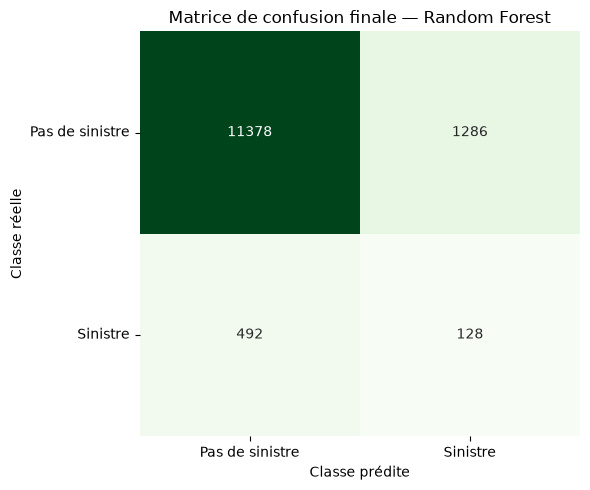

In [196]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title(
    f"Matrice de confusion finale — "
    f"{selected_model_name}"
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"]
)
plt.yticks(
    [0.5, 1.5],
    ["Pas de sinistre", "Sinistre"],
    rotation=0
)

plt.tight_layout()
plt.show()

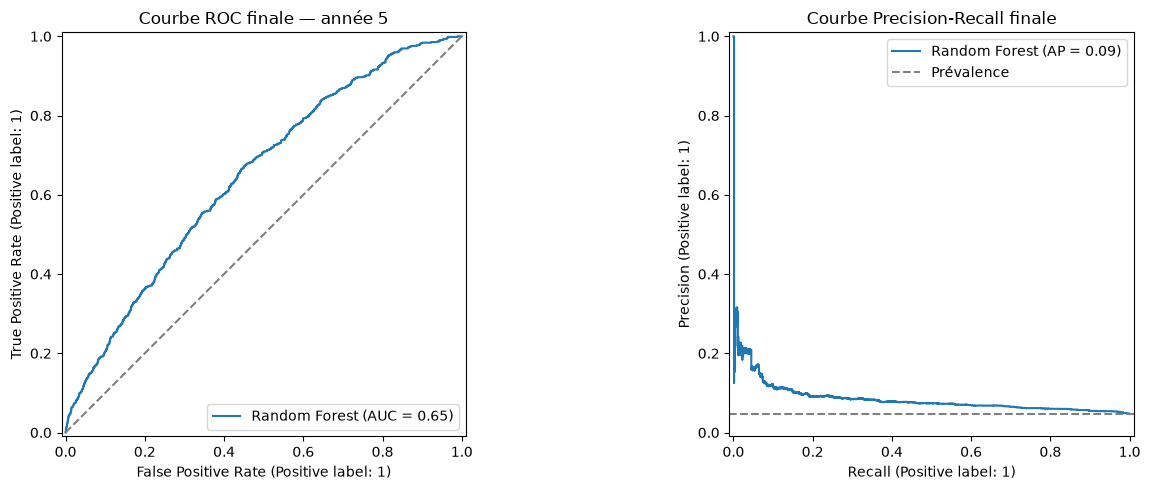

In [197]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_name,
    ax=axes[0]
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[0].set_title(
    "Courbe ROC finale — année 5"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_name,
    ax=axes[1]
)

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label="Prévalence"
)

axes[1].set_title(
    "Courbe Precision-Recall finale"
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [199]:
model_directory = Path(
    "../models"
)

model_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [200]:
model_path = (
    model_directory
    / "classification_pipeline.joblib"
)

In [201]:
joblib.dump(
    final_classification_pipeline,
    model_path
)

print(
    f"Pipeline enregistré dans : "
    f"{model_path}"
)

Pipeline enregistré dans : ..\models\classification_pipeline.joblib


In [202]:
metadata = {
    "model_name": selected_model_name,
    "target": target_column,
    "threshold": float(selected_threshold),
    "train_years": [1, 2, 3, 4],
    "test_year": 5,
    "features": feature_columns,
    "test_metrics": {
        key: float(value)
        for key, value
        in final_test_results.items()
        if key != "Modele"
    }
}

In [203]:
metadata_path = (
    model_directory
    / "classification_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=4,
        ensure_ascii=False
    )

print(
    f"Métadonnées enregistrées dans : "
    f"{metadata_path}"
)

Métadonnées enregistrées dans : ..\models\classification_metadata.json
